# Visualizing Pyro SVI Posterior Distributions in Privugger

This notebook demonstrates how to use the new Pyro backend for Stochastic Variational Inference (SVI) in Privugger and visualize the resulting posterior distributions.

## 1. Setup and Imports

In [1]:
import os
import sys
import numpy as np
import torch
import pyro
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # For creating DataFrames from posterior samples

# Make sure we can import the local privugger package
sys.path.append('../../..') # Add parent directory to path

import privugger as pv

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

## 2. Simple Model Example

Let's start with a simple example using the identity function. This will help us understand the basic workflow of the Pyro SVI backend.

In [3]:
# Reset state
pv.reset()
pyro.clear_param_store()

# Define a simple prior distribution
age = pv.Normal("age", mu=30.0, std=5.0)

# Create dataset and program
ds = pv.Dataset(input_specs=[age])
prog = pv.Program("output", dataset=ds, output_type=pv.Float, function="../../../privugger/test/identity.py")

# Run inference with Pyro backend
print("Running SVI with Pyro backend...")
trace = pv.infer(prog, draws=1000, method="pyro", svi_steps=500)
print("Inference complete!")

Running SVI with Pyro backend...
Step 0/500 - Loss: 0.0000
Step 100/500 - Loss: 0.0353
Step 200/500 - Loss: 0.1318
Step 300/500 - Loss: 0.0746
Step 400/500 - Loss: 0.0312
Inference complete!


### Examining the Posterior

Now let's look at the posterior distribution we obtained:

In [4]:
# Examine the structure of the posterior
print("Available posterior variables:")
print(trace.posterior.data_vars)

Available posterior variables:
Data variables:
    age      (chain, draw) float32 28.01 32.12 25.42 30.22 ... 37.94 23.07 27.09
    output   (chain, draw) float32 28.01 32.12 25.42 30.22 ... 37.94 23.07 27.09


### Basic Posterior Visualizations

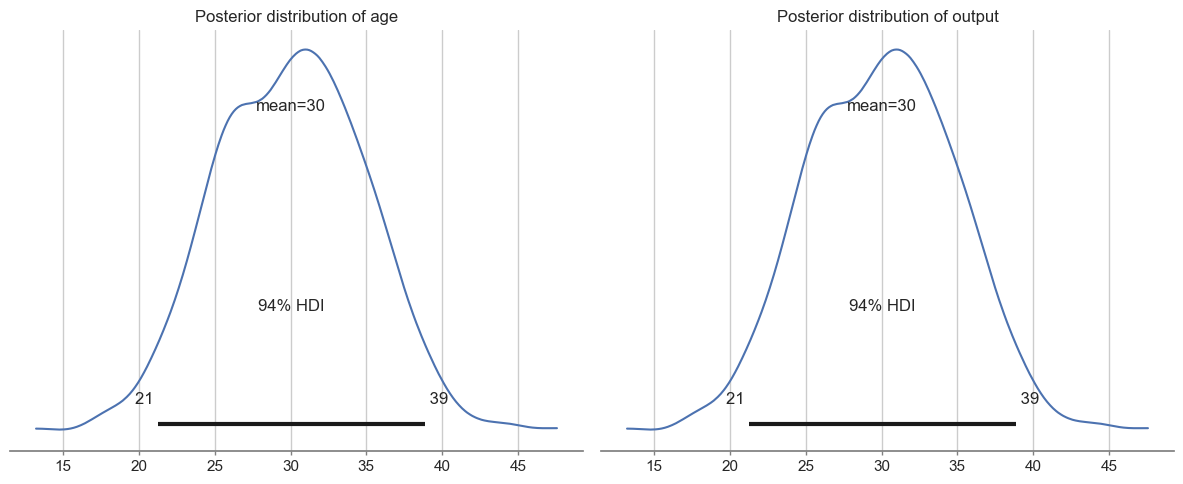

In [5]:
# Basic posterior plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot the posterior distribution for age
az.plot_posterior(trace, var_names=["age"], ax=ax[0])
ax[0].set_title("Posterior distribution of age")

# Plot the posterior distribution for output
az.plot_posterior(trace, var_names=["output"], ax=ax[1])
ax[1].set_title("Posterior distribution of output")

plt.tight_layout()
plt.show()

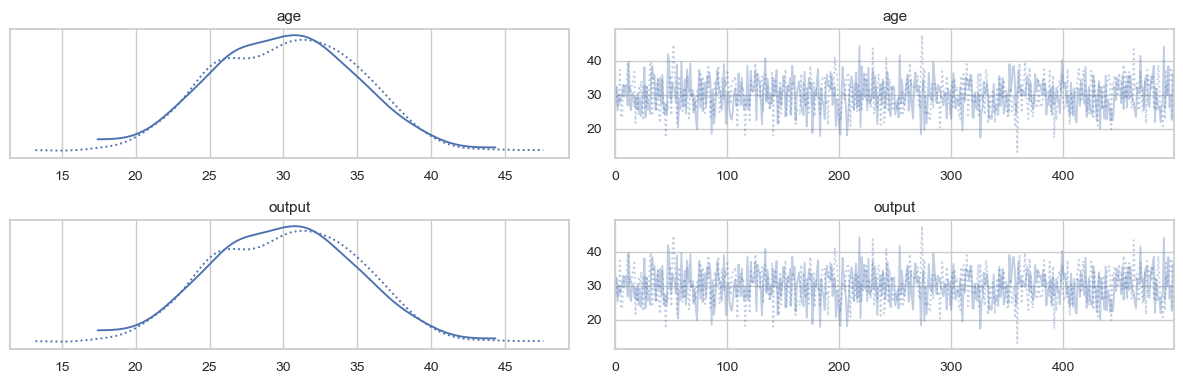

In [6]:
# Plot trace
az.plot_trace(trace)
plt.tight_layout()
plt.show()

### Kernel Density Estimate for More Detail

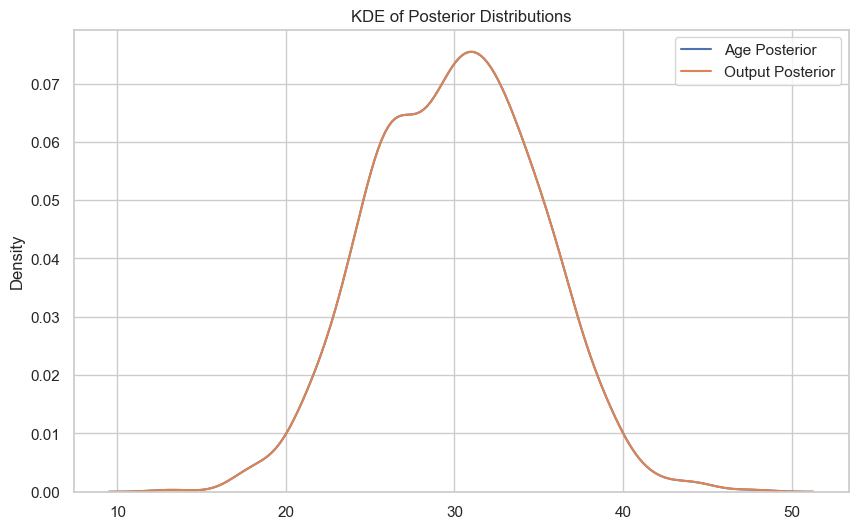

In [7]:
# Kernel Density Estimate plot for a more detailed view
plt.figure(figsize=(10, 6))
sns.kdeplot(trace.posterior.age.values.flatten(), label="Age Posterior")
sns.kdeplot(trace.posterior.output.values.flatten(), label="Output Posterior")
plt.title("KDE of Posterior Distributions")
plt.legend()
plt.show()

## 3. Advanced Model with Multiple Priors

Now let's try a more complex model with multiple input variables (priors).

In [9]:
# Reset state
pv.reset()
pyro.clear_param_store()

# Define multiple priors
age = pv.Normal("age", mu=25.0, std=3.0)
height = pv.Normal("height", mu=170.0, std=10.0)

# Create dataset and program for addition
ds = pv.Dataset(input_specs=[age, height])
prog = pv.Program("sum_output", dataset=ds, output_type=pv.Float, function="../../../privugger/test/addition.py")

# Run inference
print("Running SVI with Pyro backend for addition model...")
trace = pv.infer(prog, draws=1000, method="pyro", svi_steps=500)
print("Inference complete!")

Running SVI with Pyro backend for addition model...
Step 0/500 - Loss: 3.2468
Step 100/500 - Loss: 3.3315
Step 200/500 - Loss: 3.8092


c:\Users\tommc\anaconda3\envs\privugger\Lib\site-packages\pyro\util.py:303: UserWarning: Found vars in model but not guide: {'height'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


Step 300/500 - Loss: 3.1873
Step 400/500 - Loss: 3.3178
Inference complete!


### Visualizing Joint Posterior Distributions

<Figure size 1200x1000 with 0 Axes>

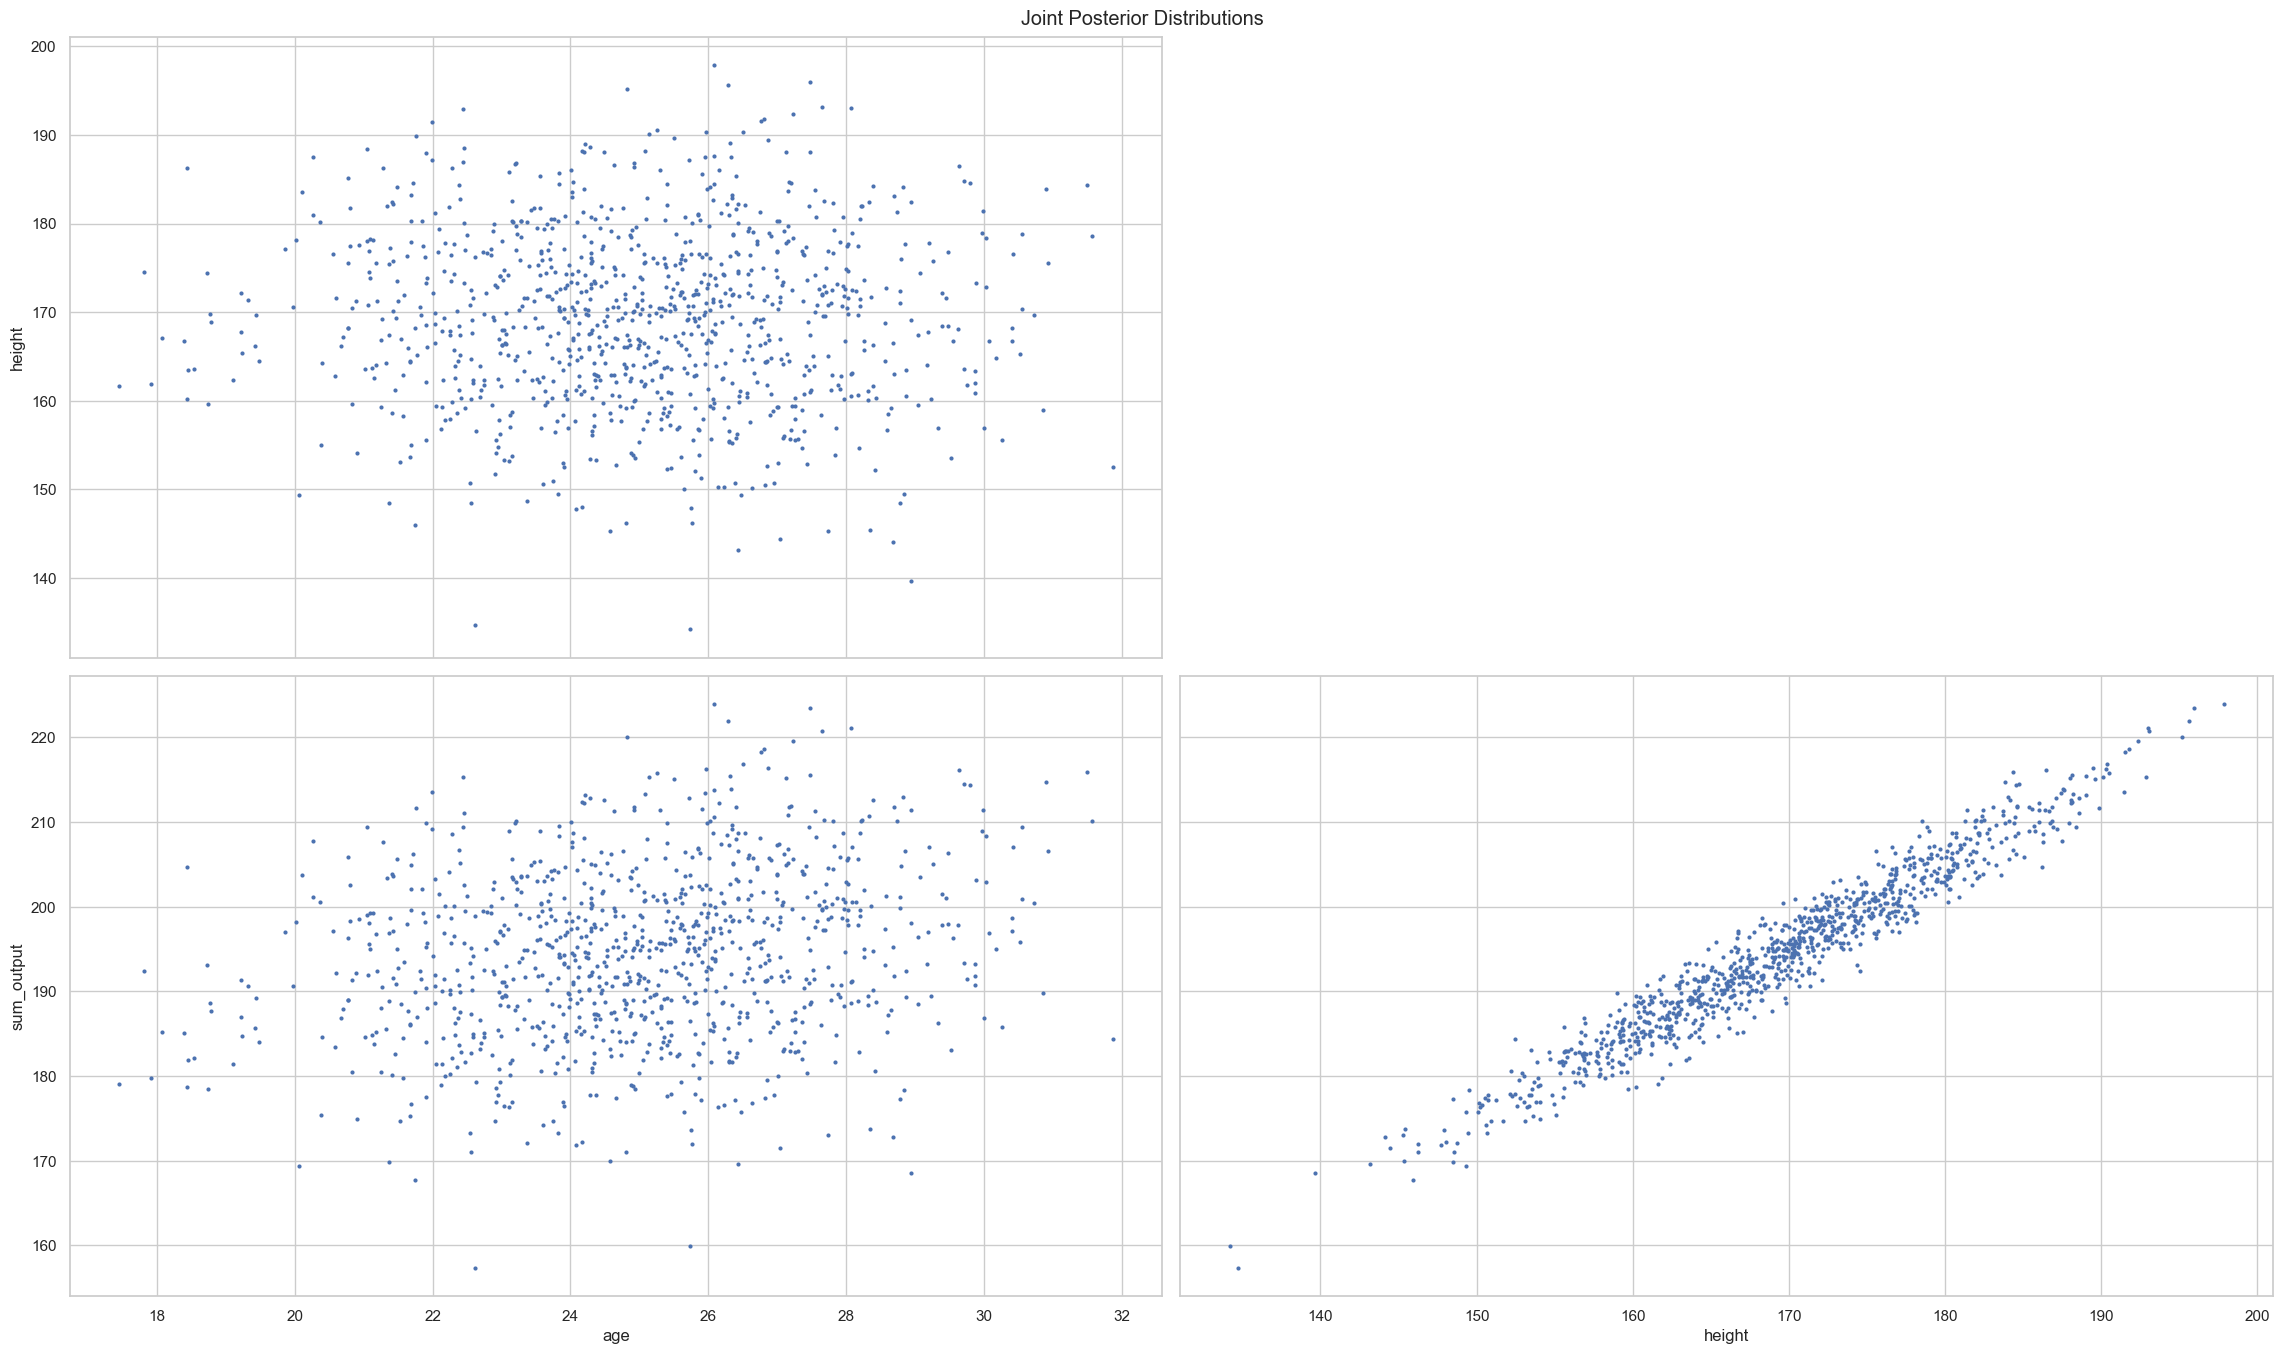

In [10]:
# Plot joint posterior
plt.figure(figsize=(12, 10))
az.plot_pair(trace, var_names=["age", "height", "sum_output"], kind='scatter')
plt.suptitle("Joint Posterior Distributions")
plt.tight_layout()
plt.show()

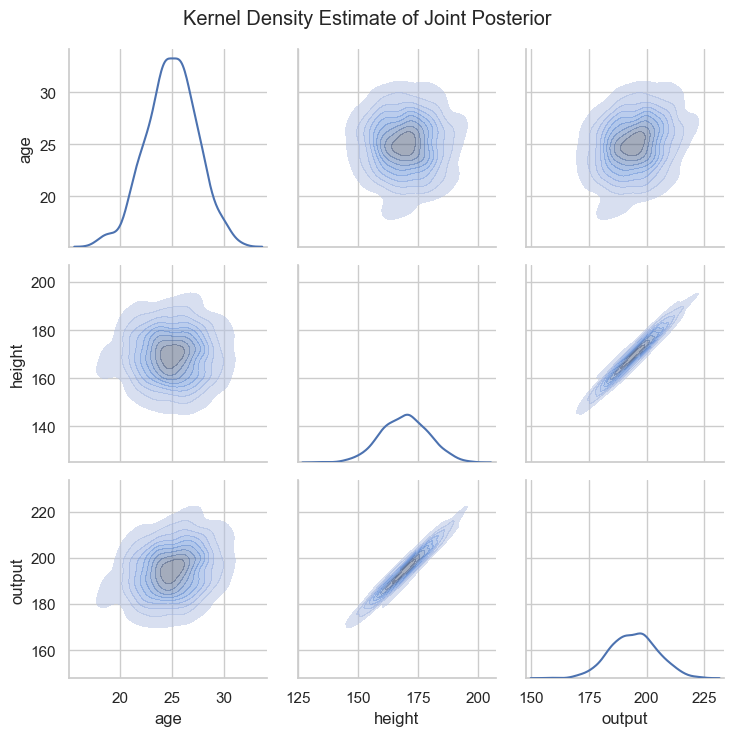

In [11]:
# Create a DataFrame for easier plotting
posterior_df = pd.DataFrame({
    'age': trace.posterior.age.values.flatten(),
    'height': trace.posterior.height.values.flatten(),
    'output': trace.posterior.sum_output.values.flatten()
})

# Plot conditional KDE
g = sns.PairGrid(data=posterior_df)
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.kdeplot, fill=True, alpha=0.5)
plt.suptitle("Kernel Density Estimate of Joint Posterior")
plt.tight_layout()
plt.show()

## 4. Comparing Inference Methods

Let's compare the results between PyMC and Pyro backends for the same simple model.

In [10]:
# Reset state
pv.reset()

# Define prior
age = pv.Normal("age", mu=25.0, std=3.0)

# Create dataset and program
ds = pv.Dataset(input_specs=[age])
prog = pv.Program("output", dataset=ds, output_type=pv.Float, function="../privugger/test/identity.py")

# Run inference with PyMC backend
print("Running inference with PyMC backend...")
pymc_trace = pv.infer(prog, draws=1000, method="pymc3")
print("PyMC inference complete!")

# Reset and run with Pyro
pv.reset()
print("Running inference with Pyro backend...")
pyro_trace = pv.infer(prog, draws=1000, method="pyro", svi_steps=500)
print("Pyro inference complete!")

Auto-assigning NUTS sampler...


Running inference with PyMC backend...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [age]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


PyMC inference complete!
Running inference with Pyro backend...
Step 0/500 - Loss: 0.0000
Step 100/500 - Loss: -0.0471
Step 200/500 - Loss: -0.0575
Step 300/500 - Loss: 0.0670
Step 400/500 - Loss: 0.6236
Pyro inference complete!


### Comparing Posterior Distributions from Different Backends

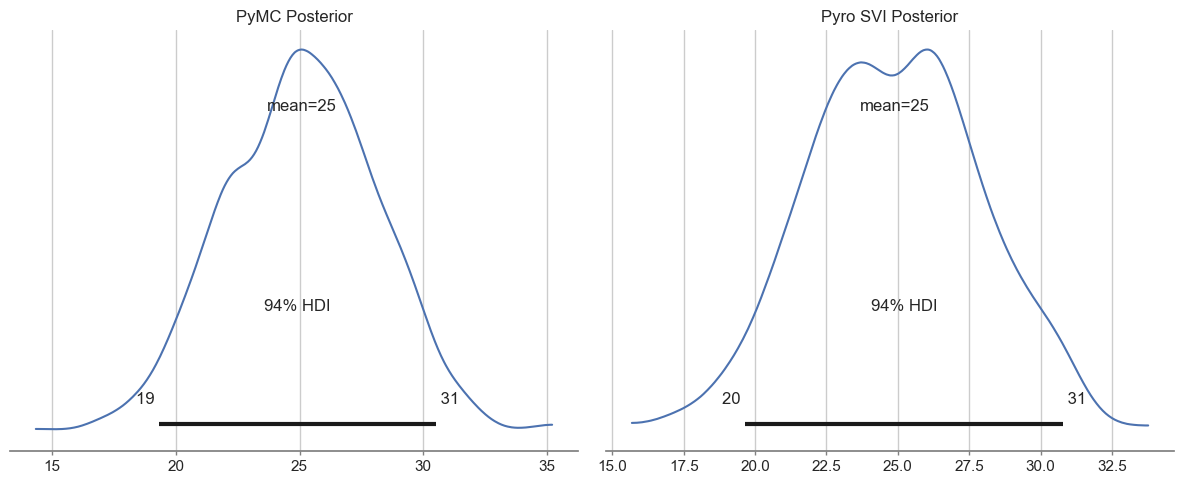

In [11]:
# Compare posteriors
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
az.plot_posterior(pymc_trace, var_names=["output"], ax=axes[0])
axes[0].set_title("PyMC Posterior")
az.plot_posterior(pyro_trace, var_names=["output"], ax=axes[1])
axes[1].set_title("Pyro SVI Posterior")
plt.tight_layout()
plt.show()

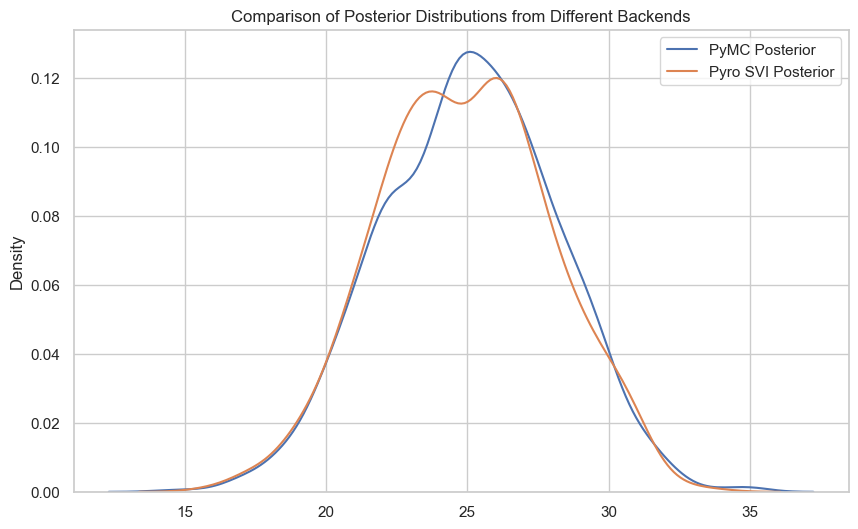

In [12]:
# KDE comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(pymc_trace.posterior.output.values.flatten(), label="PyMC Posterior")
sns.kdeplot(pyro_trace.posterior.output.values.flatten(), label="Pyro SVI Posterior")
plt.title("Comparison of Posterior Distributions from Different Backends")
plt.legend()
plt.show()

## 5. Custom Model with Interesting Posterior Shape

Now let's create a more complex model that will generate an interesting posterior shape.

In [13]:
# Create a temporary complex function file
temp_file_path = os.path.join("..", "temp_complex_function.py")
with open(temp_file_path, "w") as f:
    f.write("""import torch

def name(x, y):
    return torch.sin(x) * y + 0.1 * torch.randn_like(x)
""")

# Reset state
pv.reset()
pyro.clear_param_store()

# Define priors with wider ranges to see interesting posterior shapes
x = pv.Uniform("x", lower=0.0, upper=2*np.pi)
y = pv.Normal("y", mu=1.0, std=0.5)

# Create dataset and program
ds = pv.Dataset(input_specs=[x, y])
prog = pv.Program("output", dataset=ds, output_type=pv.Float, function=temp_file_path)

# Run inference with more samples to better visualize the posterior
print("Running SVI for complex model...")
trace = pv.infer(prog, draws=2000, method="pyro", svi_steps=1000)
print("Inference complete!")

Running SVI for complex model...
Step 0/1000 - Loss: 2.2835
Step 100/1000 - Loss: 1.9803


c:\Users\tommc\Documents\MSc-Courses\privugger\notebooks\..\privugger\inference\pyro_backend.py:177: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(init_value, dtype=torch.float32)
c:\Users\tommc\anaconda3\envs\privugger\Lib\site-packages\pyro\util.py:303: UserWarning: Found vars in model but not guide: {'y'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


Step 200/1000 - Loss: 1.0204
Step 300/1000 - Loss: 0.3810
Step 400/1000 - Loss: 0.2706
Step 500/1000 - Loss: 1.0413
Step 600/1000 - Loss: 0.5545
Step 700/1000 - Loss: 0.4742
Step 800/1000 - Loss: 0.4714
Step 900/1000 - Loss: 2.7535
Inference complete!


### 2D Visualization of Joint Posterior

<Figure size 1000x800 with 0 Axes>

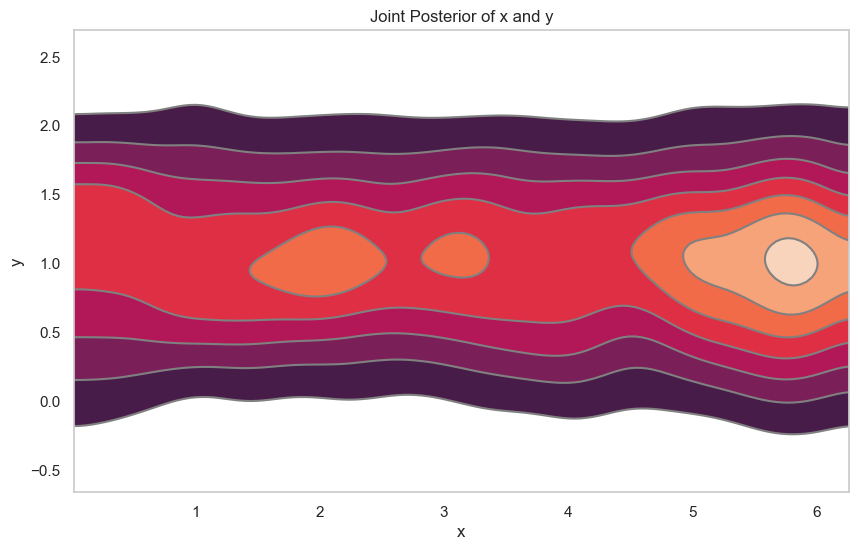

In [14]:
# Visualize 2D posterior
plt.figure(figsize=(10, 8))
az.plot_pair(trace, var_names=["x", "y"], kind='kde')
plt.title("Joint Posterior of x and y")
plt.show()

### 3D Visualization of Posterior

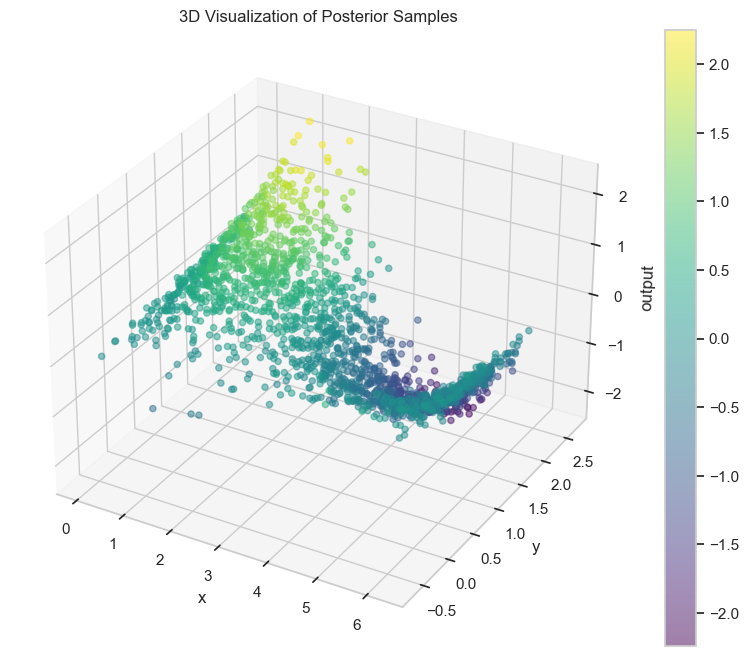

In [15]:
# 3D visualization
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract samples
x_samples = trace.posterior.x.values.flatten()
y_samples = trace.posterior.y.values.flatten()
out_samples = trace.posterior.output.values.flatten()

# Create a scatter plot
scatter = ax.scatter(x_samples, y_samples, out_samples, c=out_samples, cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('output')
plt.title("3D Visualization of Posterior Samples")
plt.show()

# Clean up the temporary file
os.remove(temp_file_path)

## 6. Additional Visualizations for SVI Results

Let's also explore some additional visualizations specific to SVI results.

In [16]:
# Reset state
pv.reset()
pyro.clear_param_store()

# Define a simple prior distribution
age = pv.Normal("age", mu=30.0, std=5.0)

# Create dataset and program
ds = pv.Dataset(input_specs=[age])
prog = pv.Program("output", dataset=ds, output_type=pv.Float, function="../privugger/test/identity.py")

# Import pyro backend functions
from privugger.inference.pyro_backend import run_svi, generate_model, generate_guide

# Create model and guide functions
model = generate_model(prog.program, [age], name="output")
guide = generate_guide([age], target_idx=0)

# Define our parameter tracking functionality
param_history = {}

# Run SVI manually to track parameters
pyro.clear_param_store()
from pyro.optim import Adam
from pyro.infer import SVI, Trace_ELBO

# Set up the optimizer
optimizer = Adam({"lr": 0.01})

# Set up SVI with Trace_ELBO loss
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Run SVI and track parameters manually
print("Running SVI with parameter tracking...")
losses = []
num_steps = 500

for step in range(num_steps):
    loss = svi.step()
    losses.append(loss)
    
    # Track parameters every 50 steps
    if step % 50 == 0:
        # Make sure parameters exist
        if "mu_age" in pyro.get_param_store() and "sigma_age" in pyro.get_param_store():
            mu = pyro.param("mu_age").item()
            sigma = pyro.param("sigma_age").item()
            
            if "mu" not in param_history:
                param_history["mu"] = []
                param_history["sigma"] = []
                param_history["step"] = []
                param_history["loss"] = []
                
            param_history["mu"].append(mu)
            param_history["sigma"].append(sigma)
            param_history["step"].append(step)
            param_history["loss"].append(loss)
            
            print(f"Step {step}/{num_steps} - mu={mu:.4f}, sigma={sigma:.4f}, loss={loss:.4f}")
        else:
            print(f"Step {step}/{num_steps} - Loss: {loss:.4f} (parameters not available yet)")

# Get posterior samples
from privugger.inference.pyro_backend import get_posterior_samples, pyro_to_arviz
samples = get_posterior_samples(model, guide, num_samples=1000)
trace = pyro_to_arviz(samples)
print("Inference complete!")

Running SVI with parameter tracking...
Step 0/500 - mu=29.9900, sigma=4.9502, loss=0.0000
Step 50/500 - mu=29.9569, sigma=4.9842, loss=0.0084
Step 100/500 - mu=30.0209, sigma=5.4599, loss=-0.0381
Step 150/500 - mu=30.0055, sigma=5.4066, loss=-0.0063
Step 200/500 - mu=29.9756, sigma=5.3799, loss=-0.0715
Step 250/500 - mu=29.9376, sigma=5.3806, loss=0.1870
Step 300/500 - mu=30.0211, sigma=5.3048, loss=0.0129
Step 350/500 - mu=30.0708, sigma=4.9637, loss=-0.0030
Step 400/500 - mu=30.1785, sigma=4.8044, loss=0.0093
Step 450/500 - mu=30.0845, sigma=4.7730, loss=0.0458
Inference complete!


### Visualizing Parameter Convergence During SVI

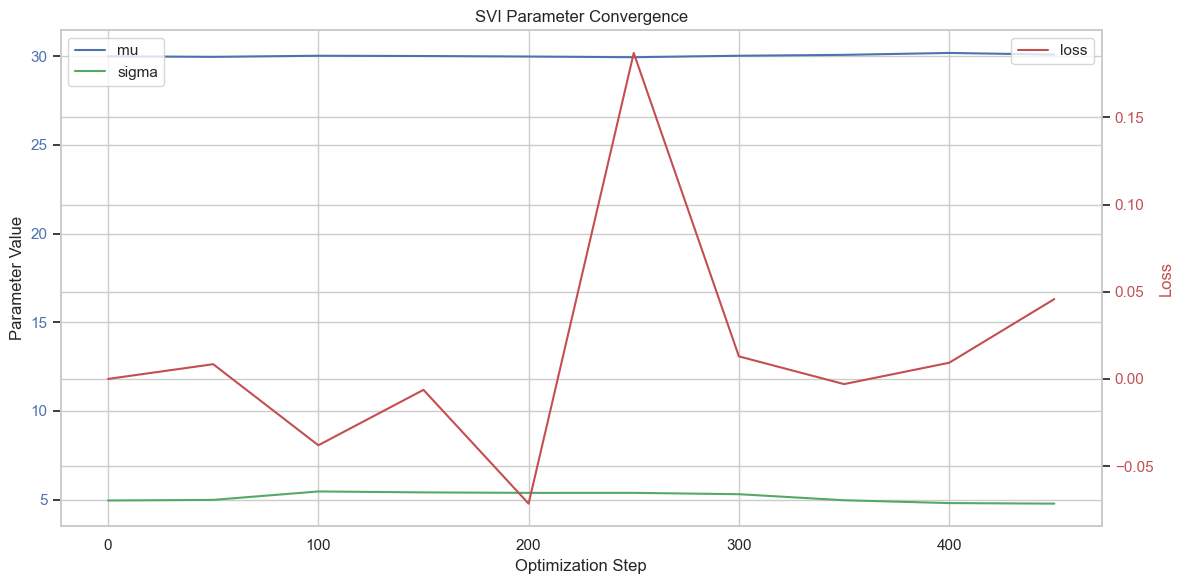

In [17]:
# Plot the parameter values over time
if param_history:
    param_df = pd.DataFrame(param_history)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot parameters
    ax1.set_xlabel('Optimization Step')
    ax1.set_ylabel('Parameter Value')
    ax1.plot(param_df['step'], param_df['mu'], 'b-', label='mu')
    ax1.plot(param_df['step'], param_df['sigma'], 'g-', label='sigma')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.legend(loc='upper left')
    
    # Create second y-axis for loss
    ax2 = ax1.twinx()
    ax2.set_ylabel('Loss', color='r')
    ax2.plot(param_df['step'], param_df['loss'], 'r-', label='loss')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.legend(loc='upper right')
    
    plt.title('SVI Parameter Convergence')
    plt.tight_layout()
    plt.show()

### Comparing Prior and Posterior Distributions

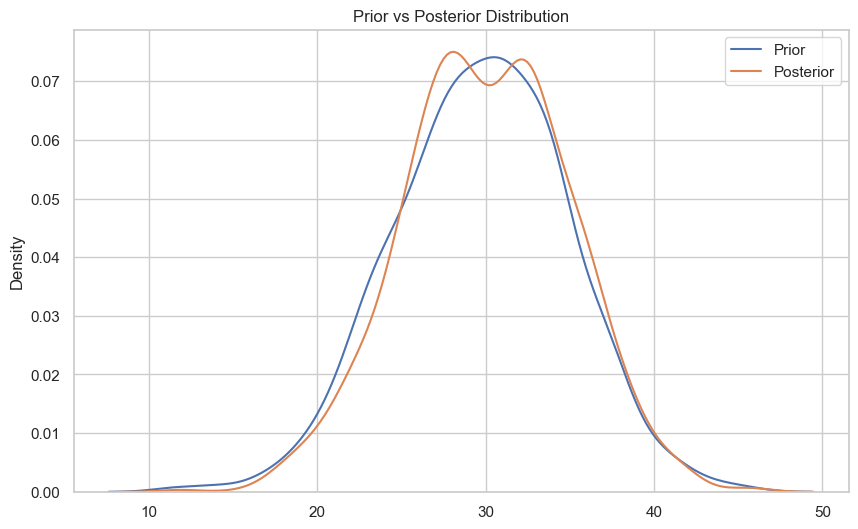

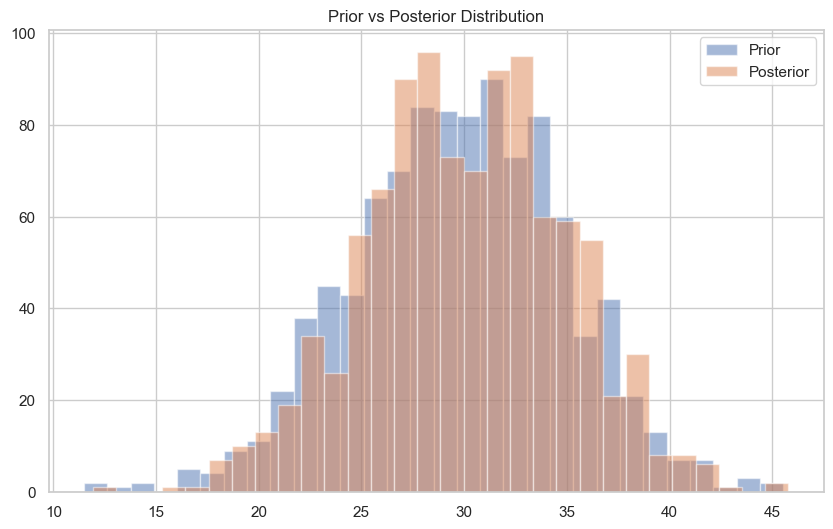

In [18]:
# Generate samples from the prior
prior_samples = np.random.normal(30.0, 5.0, size=1000)

# Get posterior samples
posterior_samples = trace.posterior.age.values.flatten()

# Compare prior and posterior
plt.figure(figsize=(10, 6))
sns.kdeplot(prior_samples, label="Prior")
sns.kdeplot(posterior_samples, label="Posterior")
plt.title("Prior vs Posterior Distribution")
plt.legend()
plt.show()

# Compare as histograms
plt.figure(figsize=(10, 6))
plt.hist(prior_samples, alpha=0.5, bins=30, label="Prior")
plt.hist(posterior_samples, alpha=0.5, bins=30, label="Posterior")
plt.title("Prior vs Posterior Distribution")
plt.legend()
plt.show()